# 1. 데이터 전처리

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# pandas 출력 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [2]:
music_df = pd.read_csv('../../01_data/raw/train.csv')
census_df = pd.read_csv('../../01_data/raw/acs2015_census_tract_data.csv')

In [3]:
# location 오타 수정
music_df['location'] = music_df['location'].replace({
    'Nebrasksa': 'Nebraska'
})

In [4]:
# 원본 데이터 기본 점검
music_raw = music_df.copy()
census_raw = census_df.copy()

print(f"music_df shape: {music_df.shape}")
print(f"census_df shape: {census_df.shape}")

raw_summary_music = pd.DataFrame({
    'dtype': music_df.dtypes.astype(str),
    'missing_cnt': music_df.isna().sum(),
    'missing_ratio(%)': (music_df.isna().mean() * 100).round(2),
    'nunique': music_df.nunique(dropna=False)
}).sort_values(['missing_cnt', 'nunique'], ascending=[False, False])

display(raw_summary_music)

num_cols_music = music_df.select_dtypes(include=np.number).columns.tolist()
cat_cols_music = music_df.select_dtypes(exclude=np.number).columns.tolist()

print("수치형 컬럼:", num_cols_music)
print("범주형 컬럼:", cat_cols_music)

display(music_df[num_cols_music].describe().T)

print("\n[churned 분포]")
display(
    music_df['churned']
    .value_counts(dropna=False)
    .rename_axis('churned')
    .reset_index(name='count')
    .assign(ratio=lambda x: (x['count'] / len(music_df) * 100).round(2))
)

eda_cat_cols = ['location', 'subscription_type', 'payment_plan', 'payment_method', 'customer_service_inquiries']
for col in eda_cat_cols:
    print(f"\n[{col}]")
    display(
        music_df[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name='count')
        .assign(ratio=lambda x: (x['count'] / len(music_df) * 100).round(2))
        .head(20)
    )

music_df shape: (125000, 20)
census_df shape: (74001, 37)


,dtype,missing_cnt,missing_ratio(%),nunique
customer_id,int64,0,0.0000,125000
weekly_hours,float64,0,0.0000,125000
average_session_length,float64,0,0.0000,124996
song_skip_rate,float64,0,0.0000,124995
signup_date,int64,0,0.0000,2922
weekly_songs_played,int64,0,0.0000,497
weekly_unique_songs,int64,0,0.0000,297
num_platform_friends,int64,0,0.0000,200
num_playlists_created,int64,0,0.0000,100
age,int64,0,0.0000,62


수치형 컬럼: ['customer_id', 'age', 'num_subscription_pauses', 'signup_date', 'weekly_hours', 'average_session_length', 'song_skip_rate', 'weekly_songs_played', 'weekly_unique_songs', 'num_favorite_artists', 'num_platform_friends', 'num_playlists_created', 'num_shared_playlists', 'notifications_clicked', 'churned']
범주형 컬럼: ['location', 'subscription_type', 'payment_plan', 'payment_method', 'customer_service_inquiries']


,count,mean,std,min,25%,50%,75%,max
customer_id,"125,000.0000","62,500.5000","36,084.5362",1.0000,"31,250.7500","62,500.5000","93,750.2500","125,000.0000"
age,"125,000.0000",48.4141,17.9010,18.0000,33.0000,48.0000,64.0000,79.0000
num_subscription_pauses,"125,000.0000",1.9911,1.4172,0.0000,1.0000,2.0000,3.0000,4.0000
signup_date,"125,000.0000","-1,460.6789",844.1329,"-2,922.0000","-2,190.0000","-1,462.0000",-728.0000,-1.0000
weekly_hours,"125,000.0000",25.0370,14.4475,0.0001,12.4727,25.1167,37.5703,49.9999
average_session_length,"125,000.0000",60.4217,34.3838,1.0005,30.6442,60.3410,90.2342,119.9965
song_skip_rate,"125,000.0000",0.5008,0.2887,0.0000,0.2510,0.5012,0.7511,1.0000
weekly_songs_played,"125,000.0000",250.8239,143.3276,3.0000,127.0000,251.0000,375.0000,499.0000
weekly_unique_songs,"125,000.0000",150.7833,85.7950,3.0000,76.0000,150.0000,225.0000,299.0000
num_favorite_artists,"125,000.0000",24.4999,14.4460,0.0000,12.0000,25.0000,37.0000,49.0000



[churned 분포]


...

,payment_plan,count,ratio
0,Monthly,62562,50.0500
1,Yearly,62438,49.9500



[payment_method]


,payment_method,count,ratio
0,Debit Card,31292,25.0300
1,Paypal,31282,25.0300
2,Credit Card,31213,24.9700
3,Apple Pay,31213,24.9700



[customer_service_inquiries]


,customer_service_inquiries,count,ratio
0,Low,41873,33.5000
1,High,41583,33.2700
2,Medium,41544,33.2400


In [5]:
# customer_id 삭제
if 'customer_id' in music_df.columns:
    music_df = music_df.drop('customer_id', axis=1)

In [6]:
income_missing_before = census_df['Income'].isna().sum()
zero_totalpop_cnt = (census_df['TotalPop'] == 0).sum()

# Census 데이터 전처리
census_df['Income'] = census_df.groupby('State')['Income'].transform(lambda x: x.fillna(x.median()))

# State별 집계
state_stats = census_df.groupby('State').agg({
    'TotalPop': 'sum',
    'Income': 'mean'
}).reset_index()

# 컬럼명 변경
state_stats.columns = ['State', 'State_TotalPop', 'State_AvgIncome']

print(f"Income 결측치(전): {income_missing_before}")
print(f"Income 결측치(후): {census_df['Income'].isna().sum()}")
print(f"TotalPop == 0 개수: {zero_totalpop_cnt}")

print("\n[state_stats 기본 통계]")
display(state_stats.describe().T)

music_states = set(music_df['location'].dropna().unique())
census_states = set(state_stats['State'].dropna().unique())

only_music = sorted(music_states - census_states)
only_census = sorted(census_states - music_states)

print("\nmusic_df에만 있는 location 값")
print(only_music)

print("\nstate_stats에만 있는 State 값")
print(only_census)

Income 결측치(전): 1100
Income 결측치(후): 0
TotalPop == 0 개수: 690

[state_stats 기본 통계]


,count,mean,std,min,25%,50%,75%,max
State_TotalPop,52.0000,"6,155,732.5769","6,992,998.8097","579,679.0000","1,792,701.7500","4,168,293.0000","6,775,555.5000","38,421,464.0000"
State_AvgIncome,52.0000,"55,919.9565","11,361.0298","20,513.9058","48,477.0198","54,188.0266","63,634.0427","78,657.1771"



music_df에만 있는 location 값
[]

state_stats에만 있는 State 값
['Alaska', 'Arizona', 'Arkansas', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'Hawaii', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Nevada', 'New Hampshire', 'New Mexico', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Puerto Rico', 'Rhode Island', 'South Dakota', 'Tennessee', 'Texas', 'Wyoming']


In [7]:
# 데이터 병합 + 병합 상태 점검
final_df = pd.merge(
    music_df,
    state_stats,
    left_on='location',
    right_on='State',
    how='left',
    indicator=True
)

print("병합 결과 요약")
display(
    final_df['_merge']
    .value_counts(dropna=False)
    .rename_axis('_merge')
    .reset_index(name='count')
    .assign(ratio=lambda x: (x['count'] / len(final_df) * 100).round(2))
)

print("\n매칭 실패 location 상위")
display(
    final_df.loc[final_df['_merge'] != 'both', 'location']
    .value_counts(dropna=False)
    .rename_axis('location')
    .reset_index(name='count')
    .head(20)
)

병합 결과 요약


,_merge,count,ratio
0,both,125000,100.0000
1,left_only,0,0.0000
2,right_only,0,0.0000



매칭 실패 location 상위


,location,count


In [8]:
# 병합 확인용 컬럼, 사용하지 않을 지역 변수 제거
final_df = final_df.drop(['State', '_merge', 'State_TotalPop'], axis=1, errors='ignore')

In [9]:
# 수치 데이터 보정
final_df['average_session_length'] = final_df['average_session_length'] / 60
final_df['weekly_unique_songs'] = np.where(
    final_df['weekly_unique_songs'] > final_df['weekly_songs_played'],
    final_df['weekly_songs_played'],
    final_df['weekly_unique_songs']
)

final_df['tenure_days'] = final_df['signup_date'].abs()
final_df = final_df.drop('signup_date', axis=1)

In [10]:
# 전처리 논리 점검
logic_check = pd.Series({
    'weekly_unique_songs > weekly_songs_played': int((final_df['weekly_unique_songs'] > final_df['weekly_songs_played']).sum()),
    'average_session_length <= 0': int((final_df['average_session_length'] <= 0).sum()),
    'song_skip_rate < 0 or > 1': int(((final_df['song_skip_rate'] < 0) | (final_df['song_skip_rate'] > 1)).sum()),
    'weekly_hours < 0': int((final_df['weekly_hours'] < 0).sum()),
    'tenure_days < 0': int((final_df['tenure_days'] < 0).sum())
}, name='count')

display(logic_check.to_frame())

print("\ntenure_days 요약")
display(final_df['tenure_days'].describe().to_frame().T)

# EDA 및 모델링용 백업
model_df = final_df.copy()

,count
weekly_unique_songs > weekly_songs_played,0
average_session_length <= 0,0
song_skip_rate < 0 or > 1,0
weekly_hours < 0,0
tenure_days < 0,0



tenure_days 요약


,count,mean,std,min,25%,50%,75%,max
tenure_days,"125,000.0000","1,460.6789",844.1329,1.0000,728.0000,"1,462.0000","2,190.0000","2,922.0000"


# 2. EDA 및 상관관계 분석

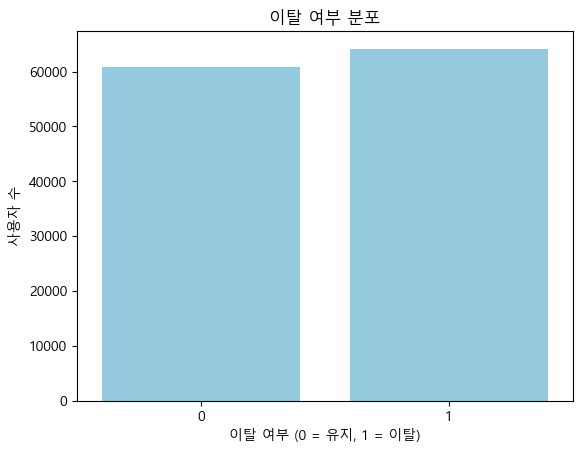

In [11]:
# 이탈 여부 분포 확인
plt.figure()
sns.countplot(data=model_df, x='churned', color='skyblue')
plt.title('이탈 여부 분포')
plt.xlabel('이탈 여부 (0 = 유지, 1 = 이탈)')
plt.ylabel('사용자 수')
plt.show()

In [12]:
# 범주형 변수 유지
cat_cols = model_df.select_dtypes(exclude=np.number).columns.tolist()
num_cols = model_df.select_dtypes(include=np.number).columns.tolist()

print("범주형 컬럼:")
print(cat_cols)

print("\n수치형 컬럼:")
print(num_cols)

범주형 컬럼:
['location', 'subscription_type', 'payment_plan', 'payment_method', 'customer_service_inquiries']

수치형 컬럼:
['age', 'num_subscription_pauses', 'weekly_hours', 'average_session_length', 'song_skip_rate', 'weekly_songs_played', 'weekly_unique_songs', 'num_favorite_artists', 'num_platform_friends', 'num_playlists_created', 'num_shared_playlists', 'notifications_clicked', 'churned', 'State_AvgIncome', 'tenure_days']


In [13]:
# 수치형 이상치(IQR) 요약
# 연속형/실수형 중심 컬럼만 선택
iqr_cols = [
    'age', 'tenure_days', 'weekly_hours', 'average_session_length', 'song_skip_rate',
    'weekly_songs_played', 'weekly_unique_songs', 'num_favorite_artists',
    'num_platform_friends', 'num_playlists_created', 'num_shared_playlists',
    'notifications_clicked', 'State_AvgIncome'
]

outlier_rows = []
for col in iqr_cols:
    q1 = model_df[col].quantile(0.25)
    q3 = model_df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    out_cnt = ((model_df[col] < lower) | (model_df[col] > upper)).sum()

    outlier_rows.append({
        'column': col,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower': lower,
        'upper': upper,
        'outlier_cnt': int(out_cnt),
        'outlier_ratio(%)': round(out_cnt / len(model_df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values('outlier_ratio(%)', ascending=False)
display(outlier_summary.head(20))

# 상관분석: 수치형 변수만 추출
corr_df = model_df.select_dtypes(include=np.number).copy()

corr_matrix = corr_df.corr(numeric_only=True)

print("\n수치형 변수 간 상관계수 행렬")
display(corr_matrix)

corr_with_target = (
    corr_matrix['churned']
    .drop('churned')
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("\nchurned와의 상관계수 상위 변수")
display(corr_with_target.to_frame('corr_with_churned'))

,column,q1,q3,iqr,lower,upper,outlier_cnt,outlier_ratio(%)
0,age,33.0000,64.0000,31.0000,-13.5000,110.5000,0,0.0000
1,tenure_days,728.0000,"2,190.0000","1,462.0000","-1,465.0000","4,383.0000",0,0.0000
2,weekly_hours,12.4727,37.5703,25.0977,-25.1738,75.2168,0,0.0000
3,average_session_length,0.5107,1.5039,0.9932,-0.9790,2.9937,0,0.0000
4,song_skip_rate,0.2510,0.7511,0.5001,-0.4992,1.5013,0,0.0000
5,weekly_songs_played,127.0000,375.0000,248.0000,-245.0000,747.0000,0,0.0000
6,weekly_unique_songs,52.0000,182.0000,130.0000,-143.0000,377.0000,0,0.0000
7,num_favorite_artists,12.0000,37.0000,25.0000,-25.5000,74.5000,0,0.0000
8,num_platform_friends,50.0000,150.0000,100.0000,-100.0000,300.0000,0,0.0000
9,num_playlists_created,24.0000,75.0000,51.0000,-52.5000,151.5000,0,0.0000



수치형 변수 간 상관계수 행렬


,age,num_subscription_pauses,weekly_hours,average_session_length,song_skip_rate,weekly_songs_played,weekly_unique_songs,num_favorite_artists,num_platform_friends,num_playlists_created,num_shared_playlists,notifications_clicked,churned,State_AvgIncome,tenure_days
age,1.0000,-0.0003,0.0018,0.0006,0.0019,-0.0017,-0.0035,0.0022,0.0010,0.0034,0.0014,-0.0001,0.0487,-0.0002,0.0016
num_subscription_pauses,-0.0003,1.0000,0.0038,0.0011,0.0063,-0.0008,-0.0033,-0.0000,-0.0009,0.0005,0.0004,0.0039,0.1830,-0.0002,-0.0031
weekly_hours,0.0018,0.0038,1.0000,0.0012,0.0057,-0.0016,0.0010,-0.0051,-0.0071,-0.0006,-0.0015,-0.0040,-0.3025,0.0016,0.0004
average_session_length,0.0006,0.0011,0.0012,1.0000,-0.0041,-0.0004,-0.0034,0.0015,-0.0001,0.0057,-0.0049,0.0002,-0.0065,-0.0015,-0.0044
song_skip_rate,0.0019,0.0063,0.0057,-0.0041,1.0000,-0.0031,0.0002,0.0016,0.0025,-0.0021,0.0016,0.0012,0.1602,0.0007,0.0025
weekly_songs_played,-0.0017,-0.0008,-0.0016,-0.0004,-0.0031,1.0000,0.4468,0.0047,0.0031,-0.0017,0.0017,-0.0026,0.0009,-0.0018,-0.0026
weekly_unique_songs,-0.0035,-0.0033,0.0010,-0.0034,0.0002,0.4468,1.0000,0.0035,-0.0027,-0.0018,-0.0001,-0.0019,0.0138,-0.0028,0.0018
num_favorite_artists,0.0022,-0.0000,-0.0051,0.0015,0.0016,0.0047,0.0035,1.0000,-0.0012,0.0038,-0.0003,-0.0001,-0.0054,0.0000,-0.0019
num_platform_friends,0.0010,-0.0009,-0.0071,-0.0001,0.0025,0.0031,-0.0027,-0.0012,1.0000,-0.0014,-0.0012,-0.0034,-0.0030,0.0028,-0.0003
num_playlists_created,0.0034,0.0005,-0.0006,0.0057,-0.0021,-0.0017,-0.0018,0.0038,-0.0014,1.0000,-0.0004,0.0006,-0.0022,-0.0011,0.0020



churned와의 상관계수 상위 변수


,corr_with_churned
weekly_hours,-0.3025
num_subscription_pauses,0.1830
song_skip_rate,0.1602
age,0.0487
notifications_clicked,-0.0424
weekly_unique_songs,0.0138
average_session_length,-0.0065
num_favorite_artists,-0.0054
num_shared_playlists,0.0038
num_platform_friends,-0.0030


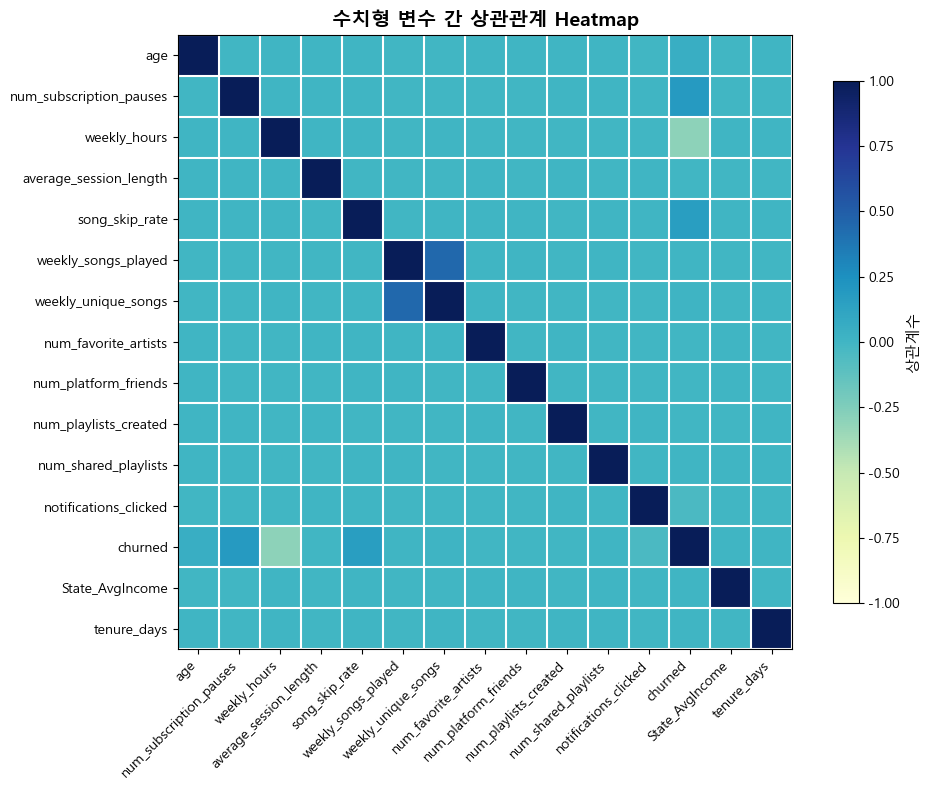

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# 수치형 변수만 추출
corr_df = model_df.select_dtypes(include=np.number).copy()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    corr_matrix,
    cmap='YlGnBu',
    vmin=-1,
    vmax=1
)

# 축 라벨
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index, fontsize=10)

# 격자선 추가
ax.set_xticks(np.arange(-.5, len(corr_matrix.columns), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(corr_matrix.index), 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=1.5)
ax.tick_params(which='minor', bottom=False, left=False)

# colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label('상관계수', fontsize=11)

ax.set_title('수치형 변수 간 상관관계 Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

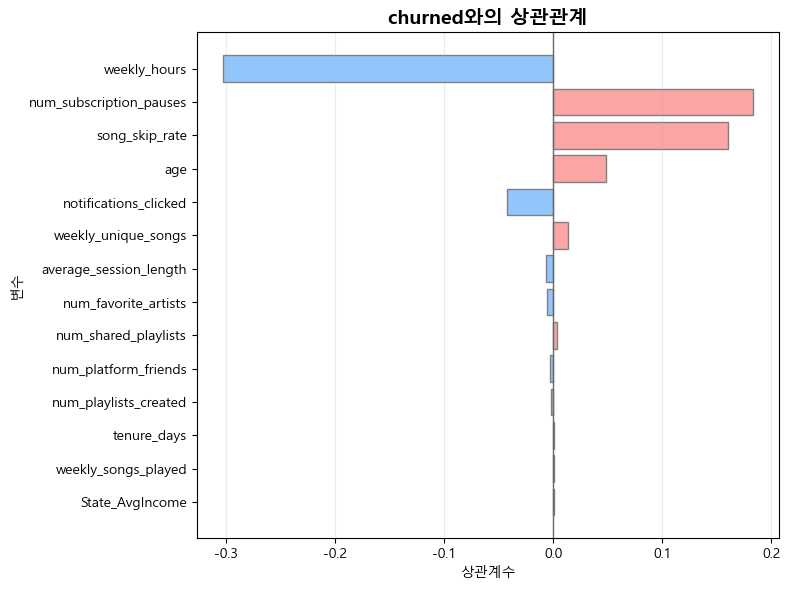

In [15]:
# churned와의 상관계수만 따로 보기
corr_with_target = (
    corr_matrix['churned']
    .drop('churned')
    .sort_values(key=lambda s: s.abs(), ascending=True)
)

plt.figure(figsize=(8, 6))

colors = ['#93c5fd' if x < 0 else '#fca5a5' for x in corr_with_target.values]

plt.barh(corr_with_target.index, corr_with_target.values, color=colors, edgecolor='gray')
plt.axvline(0, color='dimgray', linewidth=1)

plt.xlabel('상관계수')
plt.ylabel('변수')
plt.title('churned와의 상관관계', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.show()

In [16]:
# 범주형 변수 - 카이제곱 검정
from scipy.stats import chi2_contingency

cat_cols = model_df.select_dtypes(include=['object', 'string']).columns.tolist()
cat_cols = [col for col in cat_cols if col != 'churned']

result_rows = []

for col in cat_cols:
    cont_table = pd.crosstab(model_df[col], model_df['churned'])
    chi2, p, dof, expected = chi2_contingency(cont_table)

    result_rows.append({
        'variable': col,
        'chi2_stat': chi2,
        'p_value': p,
        'n_categories': model_df[col].nunique()
    })

chi2_result = pd.DataFrame(result_rows).sort_values('p_value')
display(chi2_result)

,variable,chi2_stat,p_value,n_categories
1,subscription_type,"17,626.1546",0.0000,4
4,customer_service_inquiries,"17,225.8471",0.0000,3
3,payment_method,8.1493,0.0430,4
2,payment_plan,0.2224,0.6372,2
0,location,8.0614,0.9777,19


In [17]:
def plot_categorical_churn_rate(df, col, target='churned'):
    summary = (
        df.groupby(col, as_index=False)
        .agg(
            total_users=(target, 'size'),
            churn_users=(target, 'sum'),
            churn_rate=(target, 'mean')
        )
        .sort_values('churn_rate', ascending=False)
    )
    summary['churn_rate_pct'] = (summary['churn_rate'] * 100).round(2)

    display(summary)

    plt.figure(figsize=(8, 5))
    bars = plt.bar(
        summary[col].astype(str),
        summary['churn_rate_pct'],
        color='#fbcfe8',
        edgecolor='gray'
    )

    overall_rate = df[target].mean() * 100
    plt.axhline(
        overall_rate,
        color='dimgray',
        linestyle='--',
        linewidth=1.5,
        label=f'전체 평균 이탈률: {overall_rate:.1f}%'
    )

    for bar in bars:
        y = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            y + 0.4,
            f'{y:.1f}%',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

    plt.title(f'{col}별 이탈률', fontsize=14, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('이탈률 (%)')
    plt.xticks(rotation=20)
    plt.legend(frameon=False)
    plt.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()

,subscription_type,total_users,churn_users,churn_rate,churn_rate_pct
1,Free,31269,24830,0.7941,79.4100
3,Student,31305,17967,0.5739,57.3900
0,Family,31072,10745,0.3458,34.5800
2,Premium,31354,10632,0.3391,33.9100


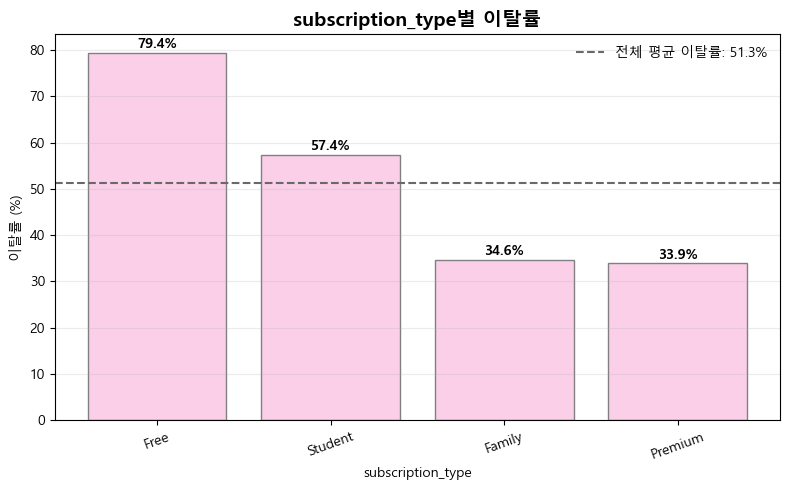

,payment_plan,total_users,churn_users,churn_rate,churn_rate_pct
0,Monthly,62562,32161,0.5141,51.4100
1,Yearly,62438,32013,0.5127,51.2700


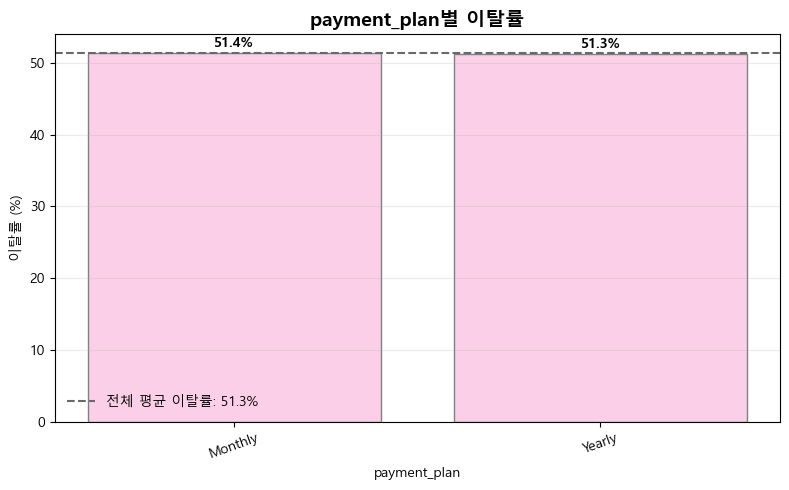

,payment_method,total_users,churn_users,churn_rate,churn_rate_pct
0,Apple Pay,31213,16198,0.5190,51.9000
2,Debit Card,31292,16115,0.5150,51.5000
3,Paypal,31282,16003,0.5116,51.1600
1,Credit Card,31213,15858,0.5081,50.8100


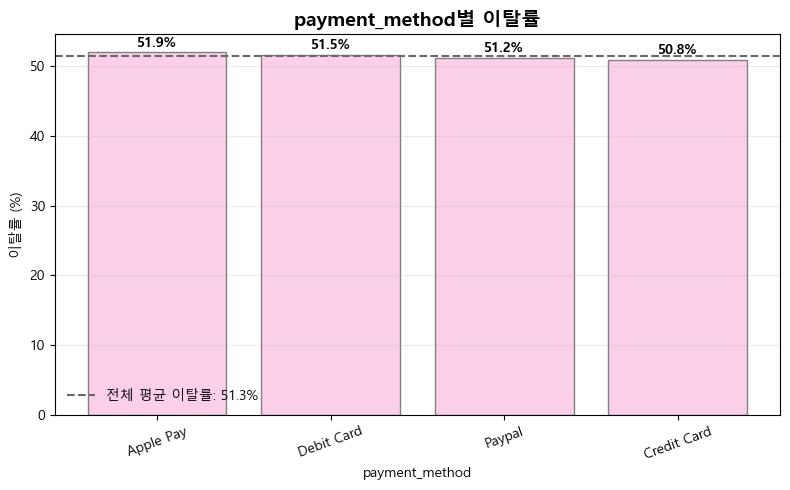

,customer_service_inquiries,total_users,churn_users,churn_rate,churn_rate_pct
0,High,41583,30910,0.7433,74.3300
2,Medium,41544,21153,0.5092,50.9200
1,Low,41873,12111,0.2892,28.9200


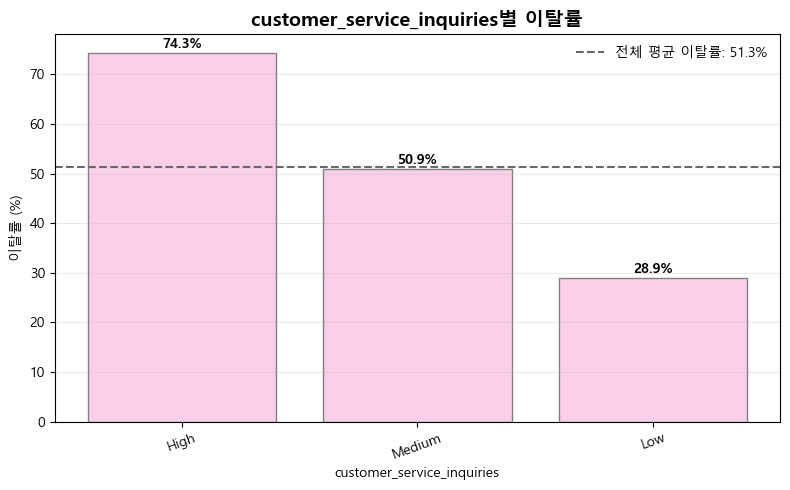

,location,total_users,churn_users,churn_rate,churn_rate_pct
1,Georgia,6705,3497,0.5216,52.1600
9,Washington,6638,3434,0.5173,51.7300
4,New Jersey,6634,3429,0.5169,51.6900
6,North Dakota,6577,3394,0.5160,51.6000
8,Vermont,6676,3442,0.5156,51.5600
7,Utah,6577,3386,0.5148,51.4800
0,California,6665,3425,0.5139,51.3900
5,North Carolina,6583,3380,0.5134,51.3400
3,Nebraska,6601,3386,0.5130,51.3000
2,Idaho,6697,3424,0.5113,51.1300


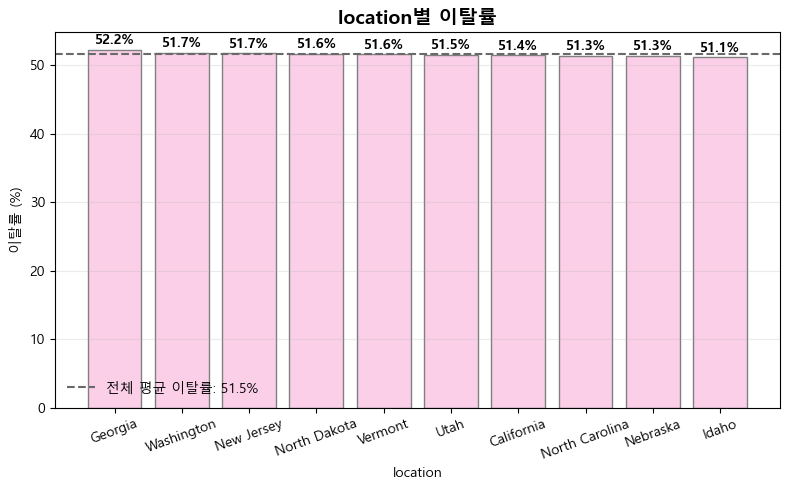

In [18]:
# 범주형 변수 시각화
plot_categorical_churn_rate(model_df, 'subscription_type')
plot_categorical_churn_rate(model_df, 'payment_plan')
plot_categorical_churn_rate(model_df, 'payment_method')
plot_categorical_churn_rate(model_df, 'customer_service_inquiries')

# location은 top 10만
top_states = model_df['location'].value_counts().head(10).index
plot_df = model_df[model_df['location'].isin(top_states)]

plot_categorical_churn_rate(plot_df, 'location')

In [19]:
def plot_categorical_stacked_bar(df, col, target='churned'):
    ratio_df = pd.crosstab(df[col], df[target], normalize='index') * 100
    ratio_df.columns = ['유지(0)', '이탈(1)']

    fig, ax = plt.subplots(figsize=(8, 5))

    colors = ['#dbeafe', '#fecaca']
    bottom = np.zeros(len(ratio_df))

    for label, color in zip(ratio_df.columns, colors):
        bars = ax.bar(
            ratio_df.index.astype(str),
            ratio_df[label],
            bottom=bottom,
            label=label,
            color=color,
            edgecolor='white',
            linewidth=1.5
        )

        for i, val in enumerate(ratio_df[label]):
            if val >= 8:
                ax.text(
                    i,
                    bottom[i] + val / 2,
                    f'{val:.1f}%',
                    ha='center',
                    va='center',
                    fontsize=9,
                    fontweight='bold'
                )

        bottom += ratio_df[label].values

    ax.set_title(f'{col}별 churn 구성비', fontsize=14, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('비율 (%)')
    ax.set_ylim(0, 100)
    ax.legend(frameon=False)
    ax.grid(axis='y', alpha=0.25)

    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

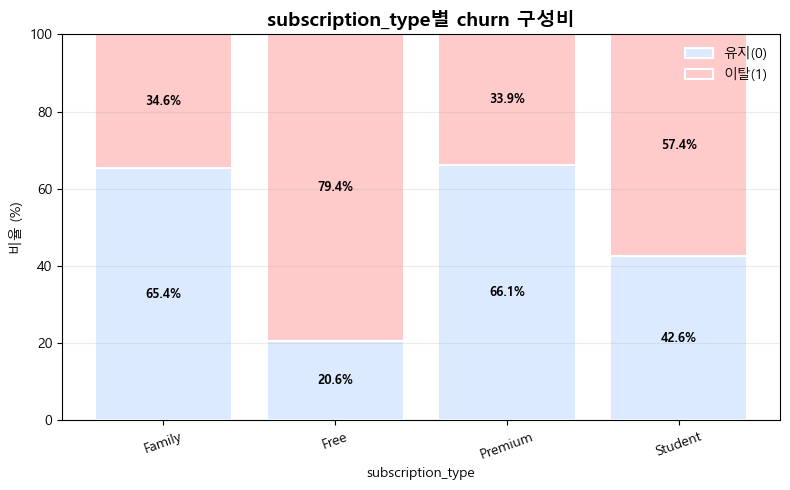

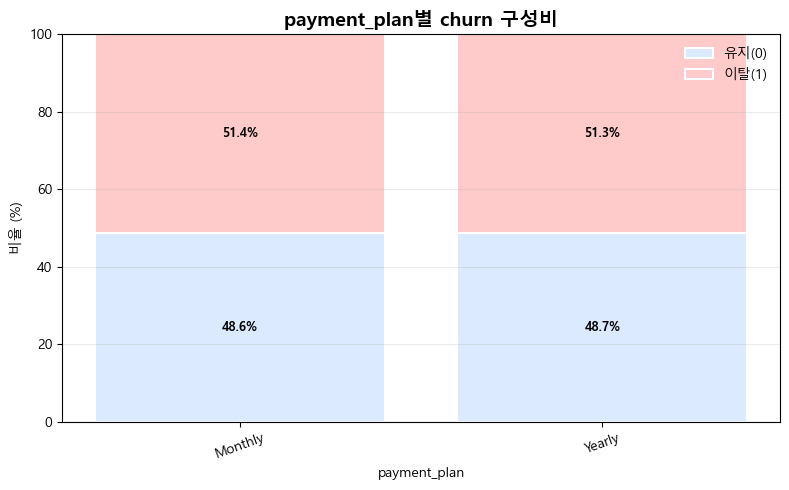

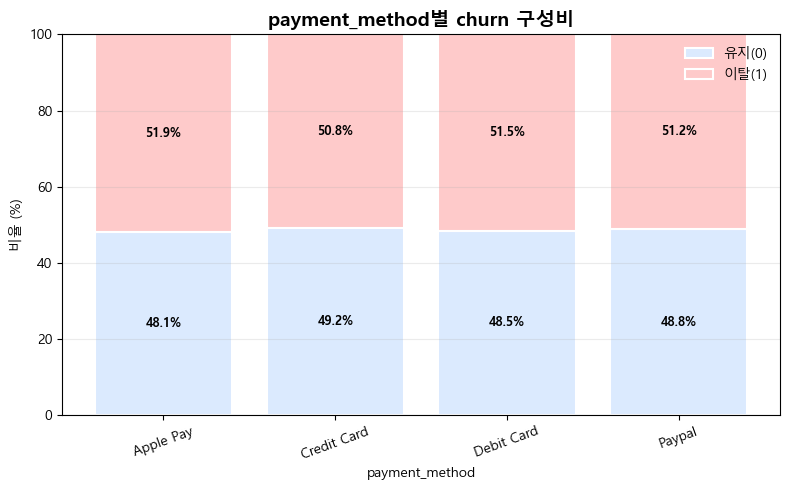

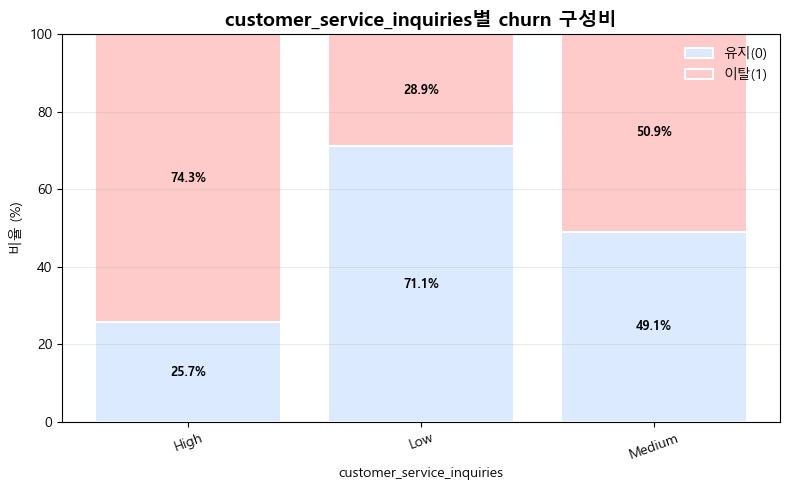

In [20]:
plot_categorical_stacked_bar(model_df, 'subscription_type')
plot_categorical_stacked_bar(model_df, 'payment_plan')
plot_categorical_stacked_bar(model_df, 'payment_method')
plot_categorical_stacked_bar(model_df, 'customer_service_inquiries')

In [21]:
# # 저장 경로 설정
# save_path = '../../01_data/processed/model_df.csv'
#
# # CSV 저장
# model_df.to_csv(save_path, index=False)
#
# print(f"파일 저장 완료: {save_path}")

# 3. 가설 검증

## 3-1. 구독 일시정지 횟수가 많을수록 이탈율이 높을 것이다.

In [22]:
# [가설 1] 구독 일시정지 횟수와 churn 관계
pause_summary = (
    model_df.groupby('num_subscription_pauses', as_index=False)
    .agg(
        total_users=('churned', 'size'),
        churn_users=('churned', 'sum'),
        churn_rate=('churned', 'mean')
    )
    .sort_values('num_subscription_pauses')
)

pause_summary['churn_rate_pct'] = (pause_summary['churn_rate'] * 100).round(2)

display(pause_summary)

# churn 여부별 평균/중앙값 비교
pause_compare = (
    model_df.groupby('churned')['num_subscription_pauses']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
)

display(pause_compare)

,num_subscription_pauses,total_users,churn_users,churn_rate,churn_rate_pct
0,0,25363,10913,0.4303,43.0300
1,1,25036,10681,0.4266,42.6600
2,2,24907,10484,0.4209,42.0900
3,3,24733,16048,0.6488,64.8800
4,4,24961,16048,0.6429,64.2900


,count,mean,median,std,min,max
churned,,,,,,
0,60826,1.7247,2.0000,1.3563,0,4
1,64174,2.2437,3.0000,1.4275,0,4


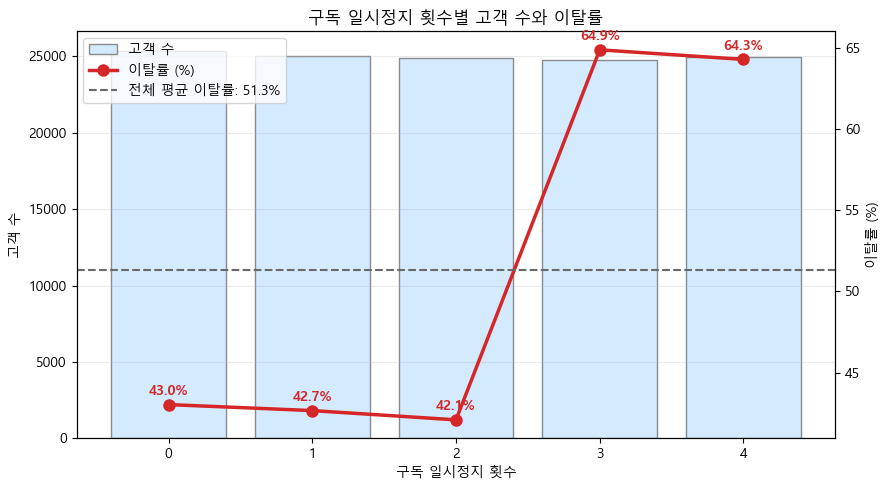

In [23]:
# 구독 일시정지 횟수별 고객 수 + 이탈률 복합 그래프
fig, ax1 = plt.subplots(figsize=(9, 5))

bar_color = '#cfe8ff'
line_color = '#d62728'

# 막대: 고객 수
bars = ax1.bar(
    pause_summary['num_subscription_pauses'],
    pause_summary['total_users'],
    color=bar_color,
    edgecolor='gray',
    linewidth=1.0,
    alpha=0.9,
    label='고객 수'
)
ax1.set_xlabel('구독 일시정지 횟수')
ax1.set_ylabel('고객 수')
ax1.set_xticks(pause_summary['num_subscription_pauses'])
ax1.grid(axis='y', alpha=0.25)

# 선: 이탈률
ax2 = ax1.twinx()
line = ax2.plot(
    pause_summary['num_subscription_pauses'],
    pause_summary['churn_rate_pct'],
    marker='o',
    markersize=8,
    linewidth=2.5,
    color=line_color,
    label='이탈률 (%)'
)
ax2.set_ylabel('이탈률 (%)')

overall_churn_rate = model_df['churned'].mean() * 100
avg_line = ax2.axhline(
    overall_churn_rate,
    color='dimgray',
    linestyle='--',
    linewidth=1.5,
    label=f'전체 평균 이탈률: {overall_churn_rate:.1f}%'
)

for x, y in zip(pause_summary['num_subscription_pauses'], pause_summary['churn_rate_pct']):
    ax2.text(x, y + 0.6, f'{y:.1f}%', ha='center', color=line_color, fontsize=10, fontweight='bold')

# 범례 합치기
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

plt.title('구독 일시정지 횟수별 고객 수와 이탈률')
plt.tight_layout()
plt.show()

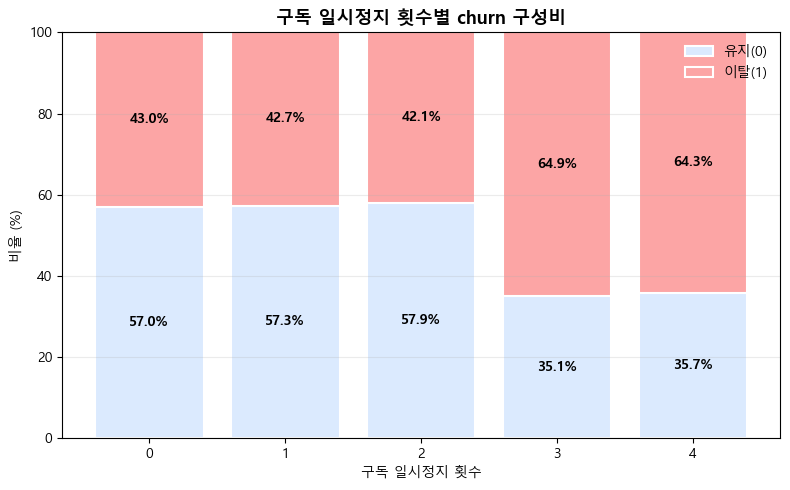

In [24]:
# 구독 일시정지 횟수별 churn 구성비
pause_ratio = pd.crosstab(
    model_df['num_subscription_pauses'],
    model_df['churned'],
    normalize='index'
) * 100

pause_ratio.columns = ['유지(0)', '이탈(1)']

fig, ax = plt.subplots(figsize=(8, 5))

keep_color = '#dbeafe'
churn_color = '#fca5a5'

bottom = np.zeros(len(pause_ratio))

for col, color in zip(pause_ratio.columns, [keep_color, churn_color]):
    bars = ax.bar(
        pause_ratio.index,
        pause_ratio[col],
        bottom=bottom,
        label=col,
        color=color,
        edgecolor='white',
        linewidth=1.5
    )

    # 각 영역 안에 퍼센트 표시
    for i, val in enumerate(pause_ratio[col]):
        if val >= 8:  # 너무 작은 값은 글씨 생략
            ax.text(
                pause_ratio.index[i],
                bottom[i] + val / 2,
                f'{val:.1f}%',
                ha='center',
                va='center',
                fontsize=10,
                fontweight='bold',
                color='black'
            )
    bottom += pause_ratio[col].values

ax.set_title('구독 일시정지 횟수별 churn 구성비', fontsize=13, fontweight='bold')
ax.set_xlabel('구독 일시정지 횟수')
ax.set_ylabel('비율 (%)')
ax.set_xticks(pause_ratio.index)
ax.set_ylim(0, 100)
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

In [25]:
# 0~2회 vs 3회 이상으로 구간화
model_df['pause_group'] = np.where(
    model_df['num_subscription_pauses'] >= 3,
    'High Pause (3-4)',
    'Low Pause (0-2)'
)

pause_group_summary = (
    model_df.groupby('pause_group', as_index=False)
    .agg(
        total_users=('churned', 'size'),
        churn_users=('churned', 'sum'),
        churn_rate=('churned', 'mean')
    )
)

pause_group_summary['churn_rate_pct'] = (pause_group_summary['churn_rate'] * 100).round(2)
display(pause_group_summary)

,pause_group,total_users,churn_users,churn_rate,churn_rate_pct
0,High Pause (3-4),49694,32096,0.6459,64.5900
1,Low Pause (0-2),75306,32078,0.4260,42.6000


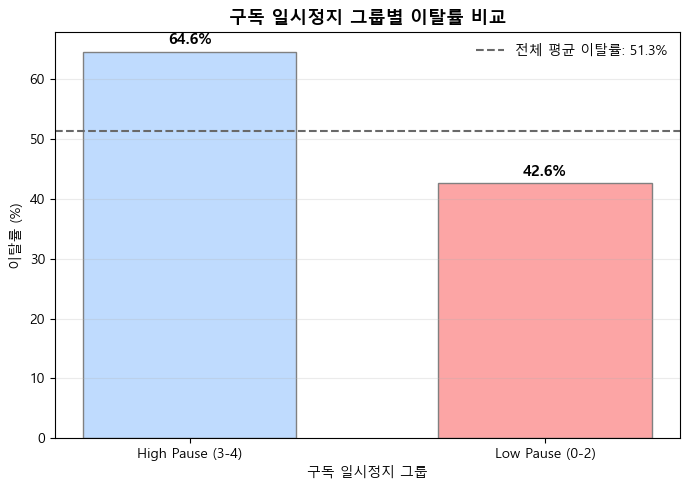

In [26]:
# Low Pause vs High Pause 비교
pause_group_summary['churn_rate_pct'] = (pause_group_summary['churn_rate'] * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 5))

bar_colors = ['#bfdbfe', '#fca5a5']

bars = ax.bar(
    pause_group_summary['pause_group'],
    pause_group_summary['churn_rate_pct'],
    color=bar_colors,
    edgecolor='gray',
    linewidth=1.0,
    width=0.6
)

overall_churn_rate = model_df['churned'].mean() * 100
ax.axhline(
    overall_churn_rate,
    color='dimgray',
    linestyle='--',
    linewidth=1.5,
    label=f'전체 평균 이탈률: {overall_churn_rate:.1f}%'
)

for bar in bars:
    y = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y + 0.6,
        f'{y:.1f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax.set_title('구독 일시정지 그룹별 이탈률 비교', fontsize=13, fontweight='bold')
ax.set_xlabel('구독 일시정지 그룹')
ax.set_ylabel('이탈률 (%)')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

## 3-2. 노래 스킵 비율이 높을수록 이탈률이 높을 것이다.

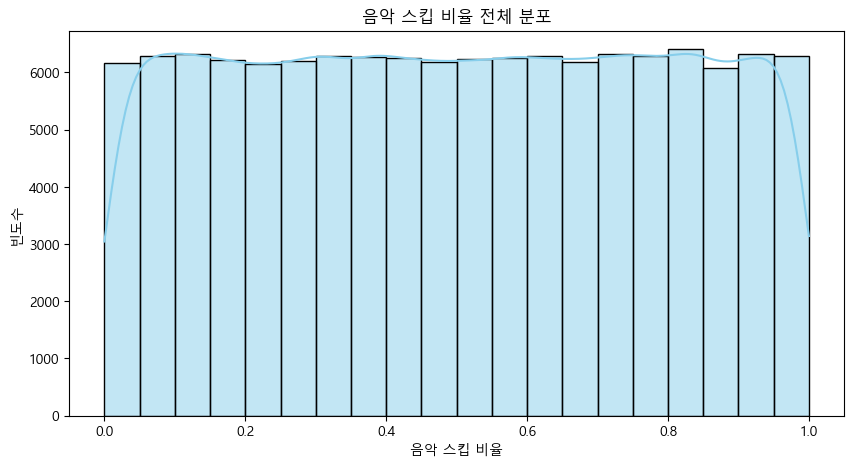

In [27]:
# 음악 스킵 비율 전체 분포
plt.figure(figsize=(10, 5))
sns.histplot(data=model_df, x='song_skip_rate', bins=20, kde=True, color='skyblue')
plt.title('음악 스킵 비율 전체 분포')
plt.xlabel('음악 스킵 비율')
plt.ylabel('빈도수')
plt.show()

In [28]:
# 이탈 여부별 음악 스킵 비율 평균 및 상관계수 확인
print("\n[이탈 여부별 음악 스킵 비율 평균]")
print(model_df.groupby('churned')['song_skip_rate'].mean())

correlation = model_df[['song_skip_rate', 'churned']].corr().iloc[0, 1]
print(f"\n노래 스킵 비율과 이탈 여부 간의 상관계수: {correlation:.4f}")


[이탈 여부별 음악 스킵 비율 평균]
churned
0   0.4533
1   0.5458
Name: song_skip_rate, dtype: float64

노래 스킵 비율과 이탈 여부 간의 상관계수: 0.1602


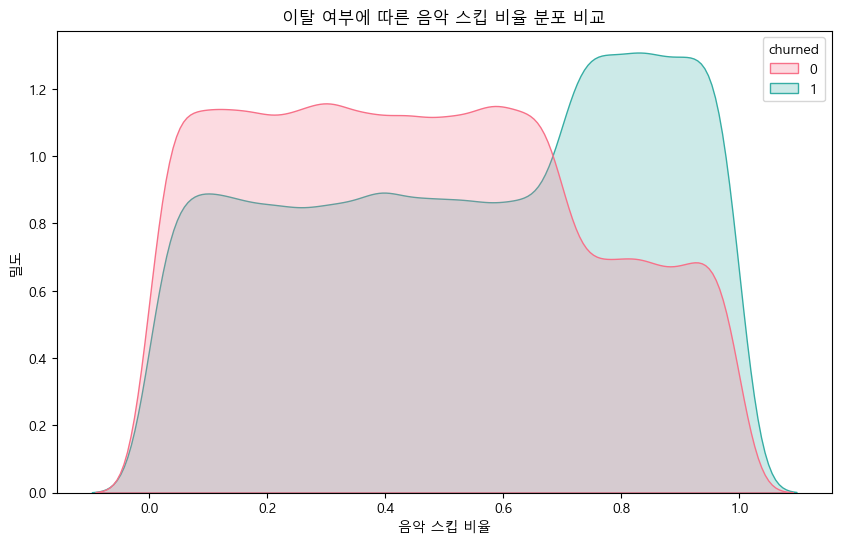

In [29]:
# 이탈 여부에 따른 음악 스킵 비율 분포 비교 (KDE Plot)
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=model_df,
    x='song_skip_rate',
    hue='churned',
    fill=True,
    common_norm=False,
    palette='husl'
)
plt.title('이탈 여부에 따른 음악 스킵 비율 분포 비교')
plt.xlabel('음악 스킵 비율')
plt.ylabel('밀도')
plt.show()

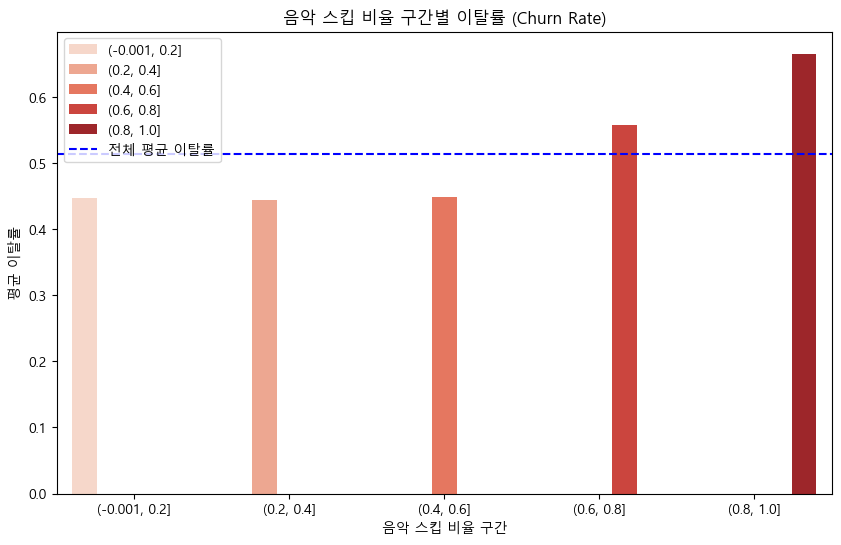

In [30]:
# 스킵 비율 구간별 이탈률 분석
model_df['skip_group'] = pd.cut(
    model_df['song_skip_rate'],
    bins=np.arange(0, 1.1, 0.2),
    include_lowest=True
)

skip_churn_rate = (
    model_df.groupby('skip_group', observed=False)['churned']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=skip_churn_rate,
    x='skip_group',
    y='churned',
    hue='skip_group',
    palette='Reds'
)
plt.axhline(
    model_df['churned'].mean(),
    color='blue',
    linestyle='--',
    label='전체 평균 이탈률'
)
plt.title('음악 스킵 비율 구간별 이탈률 (Churn Rate)')
plt.xlabel('음악 스킵 비율 구간')
plt.ylabel('평균 이탈률')
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [31]:
# 구간별 이탈률 수치
print("\n[음악 스킵 비율 구간별 이탈률]")
print(skip_churn_rate)


[음악 스킵 비율 구간별 이탈률]
      skip_group  churned
0  (-0.001, 0.2]   0.4479
1     (0.2, 0.4]   0.4443
2     (0.4, 0.6]   0.4495
3     (0.6, 0.8]   0.5578
4     (0.8, 1.0]   0.6661


## 3-3. 거주하는 주의 인당소득이 높을수록 이탈률이 낮을 것이다.

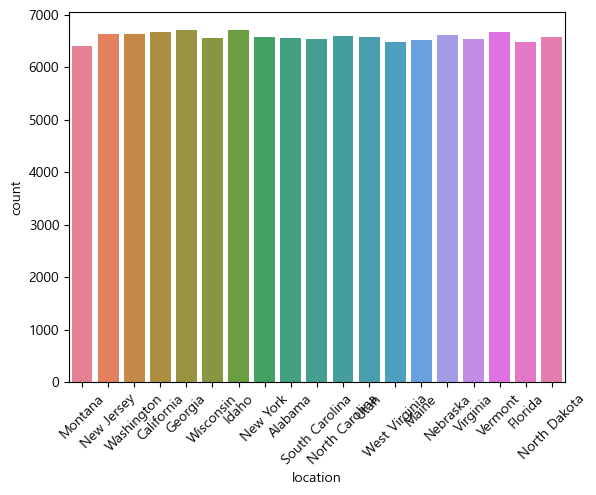

In [32]:
# 주별 인구 분포
sns.countplot(data=model_df, x='location', hue='location')
plt.xticks(rotation=45)
plt.show()

In [33]:
# 총 19개의 주
model_df['location'].nunique()

19

In [34]:
# 주 당 인구 수
location_group = model_df.groupby('location').size()

location_group

location
Alabama           6555
California        6665
Florida           6480
Georgia           6705
Idaho             6697
Maine             6523
Montana           6401
Nebraska          6601
New Jersey        6634
New York          6574
North Carolina    6583
North Dakota      6577
South Carolina    6534
Utah              6577
Vermont           6676
Virginia          6541
Washington        6638
West Virginia     6486
Wisconsin         6553
dtype: int64

In [35]:
# 주 당 평균소득
location_income = model_df.groupby('location')['State_AvgIncome'].mean()
location_income

location
Alabama          43,275.5728
California       67,180.1817
Florida          50,584.7828
Georgia          50,748.5907
Idaho            48,017.3154
Maine            49,140.9330
Montana          47,631.1568
Nebraska         55,880.7556
New Jersey       76,533.2965
New York         64,131.5279
North Carolina   49,854.5248
North Dakota     58,188.1122
South Carolina   46,227.7285
Utah             63,468.2143
Vermont          55,597.6848
Virginia         72,617.1453
Washington       64,452.0583
West Virginia    41,437.1116
Wisconsin        53,870.3300
Name: State_AvgIncome, dtype: float64

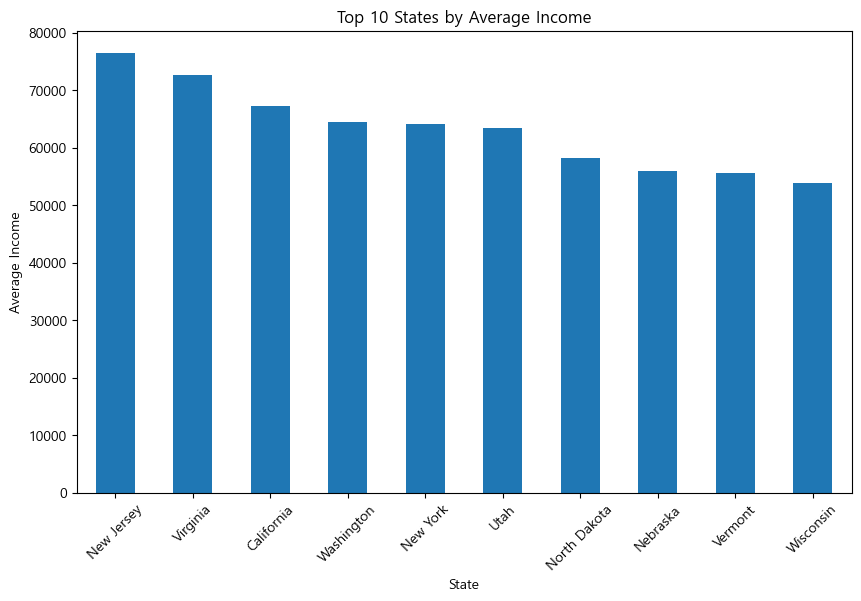

In [36]:
location_income.sort_values(ascending=False).head(10).plot(
    kind='bar', figsize=(10,6)
)

plt.xlabel('State')
plt.ylabel('Average Income')
plt.title('Top 10 States by Average Income')
plt.xticks(rotation=45)
plt.show()

In [37]:
# 주 별 이탈률과 평균 소득 같이 보기
location_churn = model_df.groupby('location')['churned'].mean()
state_analysis = model_df.groupby('location').agg({
    'State_AvgIncome': 'mean',
    'churned': 'mean'
})

state_analysis.rename(columns={'churned':'ChurnRate'}, inplace=True)

state_analysis

,State_AvgIncome,ChurnRate
location,,
Alabama,"43,275.5728",0.5105
California,"67,180.1817",0.5139
Florida,"50,584.7828",0.5082
Georgia,"50,748.5907",0.5216
Idaho,"48,017.3154",0.5113
Maine,"49,140.9330",0.5053
Montana,"47,631.1568",0.5124
Nebraska,"55,880.7556",0.5130
New Jersey,"76,533.2965",0.5169


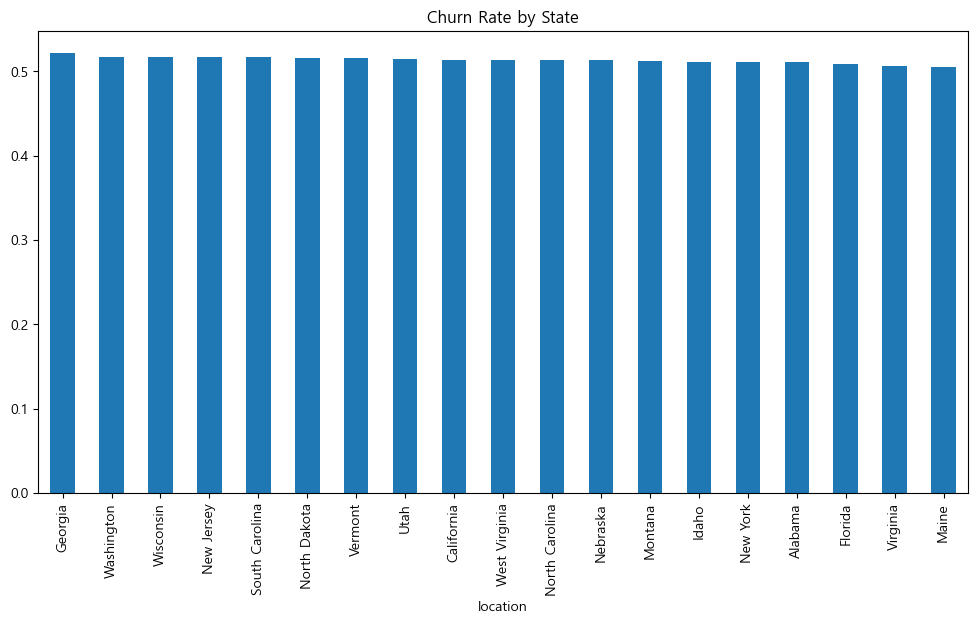

In [38]:
location_churn.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(12,6),
    title='Churn Rate by State'
)
plt.show()

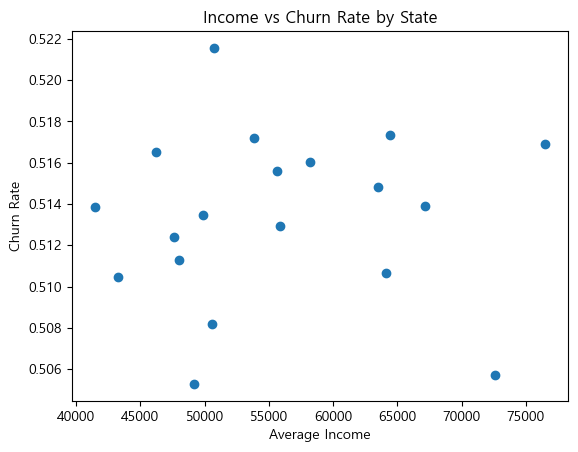

In [39]:
# 소득과 이탈률
plt.scatter(state_analysis['State_AvgIncome'], state_analysis['ChurnRate'])

plt.xlabel('Average Income')
plt.ylabel('Churn Rate')
plt.title('Income vs Churn Rate by State')

plt.show()

해석: 이탈률 값의 범위가 0.505 ~ 0.522 사이로 매우 좁고 선형관계를 찾기는 힘들다. 결과적으로 소득 수준이 높은 주라고 해서 고객 이탈률이 낮아지거나 높아지는 뚜렷한 경향은 발견되지 않았다.

+) 오른쪽 끝에 있는 이상치(outlier) 하나는 다른 주보다 소득이 훨씬 높은 주인데 이탈률은 특별히 낮지도 높지도 않음 -> 소득이 매우 높은 주에서도 이탈률이 크게 달라지지 않는다고 해석할 수 있음

In [40]:
# 단위를 thousand로 보고, Income과 churn의 상관관계
state_analysis[['State_AvgIncome','ChurnRate']].corr()

,State_AvgIncome,ChurnRate
State_AvgIncome,1.0000,0.0458
ChurnRate,0.0458,1.0000


분석: 약한 상관관계 -> 소득이 높을수록 이탈률이 아주 조금 높아지는 경향은 있지만 크게 영향이 있지는 않다.

인당 소득이 아니라 평균 소득이기에 상관관계가 약한 것이 정상적 -> 하지만 데이터 자체가 인당 이탈여부와 소득이 같이 있는 게 아니라서 매칭할 수 없으므로 인당 분석은 진행이 불가

## 3-4. 주간 청취 시간이 적을수록 이탈률이 높을 것이다

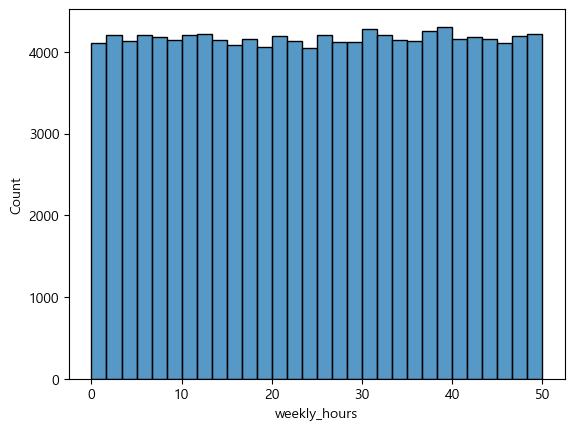

In [41]:
# 주당 청취시간 분포 확인
sns.histplot(model_df['weekly_hours'], bins=30)
plt.show()

In [42]:
# qcut으로 구간 나누고 이탈률 계산
eda_df = model_df.copy()

eda_df['hours_group'] = pd.cut(
    eda_df['weekly_hours'],
    bins=[0,15,35,50],
    labels=['Low','Medium','High']
)

hours_churn = eda_df.groupby('hours_group')['churned'].mean()
print(hours_churn)

hours_group
Low      0.7014
Medium   0.4985
High     0.3458
Name: churned, dtype: float64


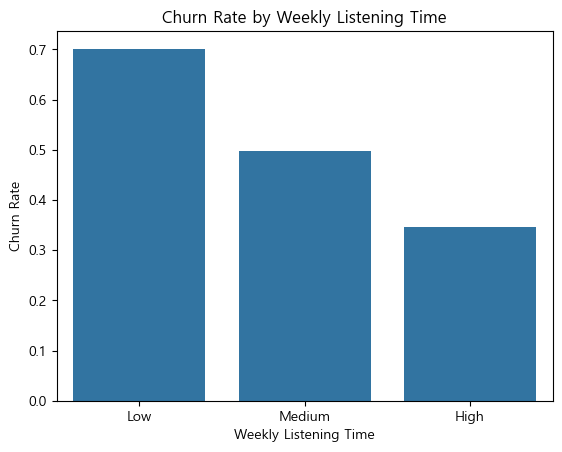

In [43]:
sns.barplot(x=hours_churn.index, y=hours_churn.values)

plt.xlabel("Weekly Listening Time")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Weekly Listening Time")

plt.show()

분석: 주간 청취 시간에 따른 고객 이탈률을 분석한 결과, 청취 시간이 낮은 사용자 그룹에서 이탈률이 상대적으로 높게 나타났다. 이는 플랫폼 이용 빈도가 낮은 사용자가 서비스에 대한 의존도가 낮아 이탈할 가능성이 높음을 시사한다.

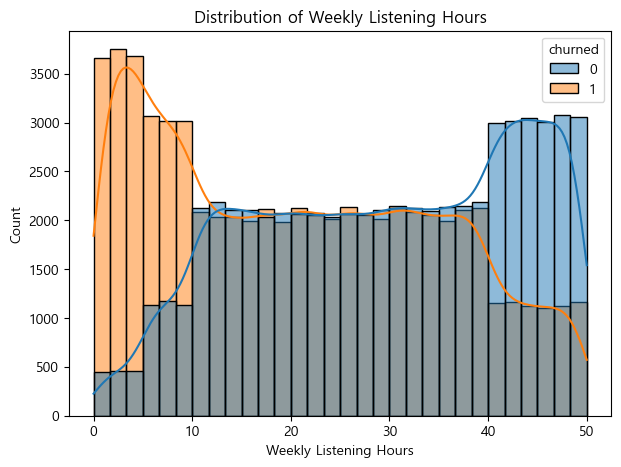

In [44]:
# churn 사용자와 active 사용자의 사용량 분포 차이
plt.figure(figsize=(7,5))

sns.histplot(
    data=eda_df,
    x='weekly_hours',
    hue='churned',
    bins=30,
    kde=True
)

plt.xlabel('Weekly Listening Hours')
plt.title('Distribution of Weekly Listening Hours')

plt.show()

## 3-5. 가입 후 경과 일수가 짧을수록 이탈률이 높을 것이다.

가설 설정 근거

- 서비스 이용 기간이 짧은 사용자일수록 플랫폼에 대한 충성도와 이용 습관이 형성되지 않았을 가능성이 높기 때문에 이탈 가능성이 높을 것으로 예상된다.

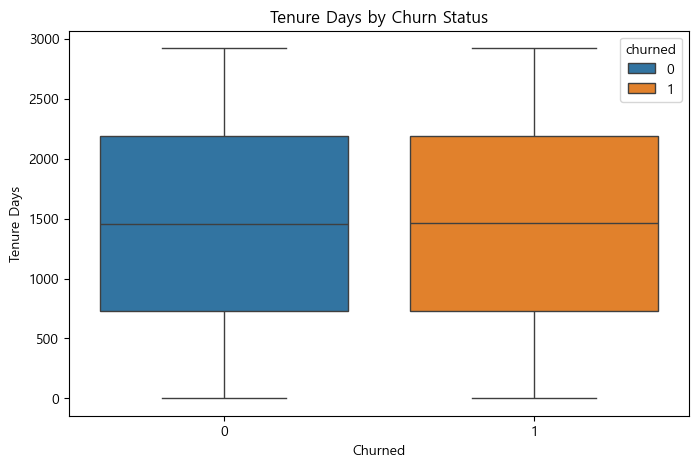

In [45]:
# Boxplot
plt.figure(figsize=(8,5))

sns.boxplot(
    x='churned',
    y='tenure_days',
    data=model_df,
    hue = 'churned',
)

plt.title('Tenure Days by Churn Status')
plt.xlabel('Churned')
plt.ylabel('Tenure Days')

plt.show()

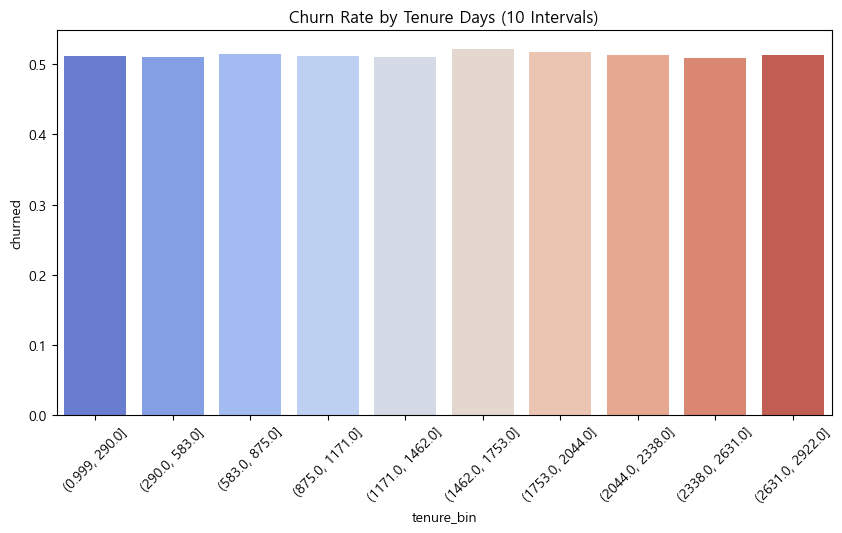

In [46]:
plt.figure(figsize=(10, 5))
model_df['tenure_bin'] = pd.qcut(model_df['tenure_days'], 10)

# 수정: observed=False 추가
tenure_churn = model_df.groupby('tenure_bin', observed=False)['churned'].mean().reset_index()
tenure_churn['tenure_bin'] = tenure_churn['tenure_bin'].astype(str)

# 수정: hue='tenure_bin' 및 legend=False 추가
sns.barplot(x='tenure_bin', y='churned', data=tenure_churn,
            hue='tenure_bin', palette='coolwarm', legend=False)

plt.title('Churn Rate by Tenure Days (10 Intervals)')
plt.xticks(rotation=45)
plt.show()

- 분석 결과: 상관관계가 거의 없음 (0.0012). 가입 기간에 상관없이 이탈률이 약 51%로 일정함.
-> 기각

## 3-6. 몰입도 점수가 낮을수록 이탈률이 높을 것이다.

가설 설정 근거

- 사용자 몰입도 점수는 플랫폼 활동량, 콘텐츠 소비 패턴 등을 종합적으로 반영하는 지표로, 몰입도가 낮을수록 서비스에 대한 관심과 사용 빈도가 낮아 이탈 가능성이 높을 것으로 예상된다.

Text(0.5, 1.0, '몰입도 점수 vs 이탈 여부')

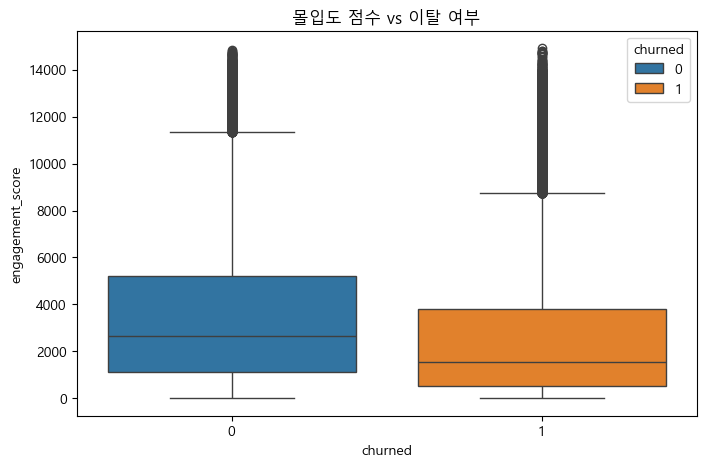

In [47]:
model_df['engagement_score'] = model_df['weekly_hours'] * model_df['weekly_unique_songs']

plt.figure(figsize=(8, 5))
sns.boxplot(x='churned', y='engagement_score', data=model_df,hue='churned')
plt.title('몰입도 점수 vs 이탈 여부')

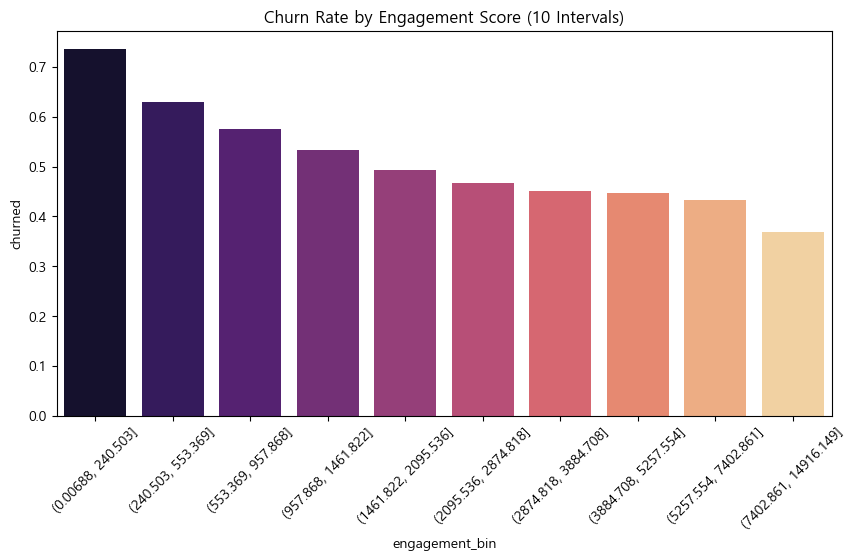

In [48]:
plt.figure(figsize=(10, 5))
model_df['engagement_bin'] = pd.qcut(model_df['engagement_score'], 10)

# 수정: observed=False 추가
eng_churn = model_df.groupby('engagement_bin', observed=False)['churned'].mean().reset_index()
eng_churn['engagement_bin'] = eng_churn['engagement_bin'].astype(str)

# 수정: hue='engagement_bin' 및 legend=False 추가
sns.barplot(x='engagement_bin', y='churned', data=eng_churn,
            hue='engagement_bin', palette='magma', legend=False)

plt.title('Churn Rate by Engagement Score (10 Intervals)')
plt.xticks(rotation=45)
plt.show()

- 분석 결과: 강한 음의 상관관계. 몰입도가 낮을수록 이탈률이 급격히 증가함.

## 3-7. 고객센터 문의 수준이 높을수록 이탈률이 높을 것이다.

가설 설정 근거

- 고객센터 문의 횟수는 사용자가 서비스 이용 과정에서 겪는 문제나 불편 사항을 간접적으로 나타내는 지표로 볼 수 있다. 일반적으로 서비스 사용 중 문제가 자주 발생하거나 만족도가 낮은 경우 고객센터 문의가 증가할 가능성이 있다. 이러한 경험이 반복될 경우 서비스에 대한 불만이 누적되어 고객 이탈로 이어질 가능성이 높을 것으로 예상된다.

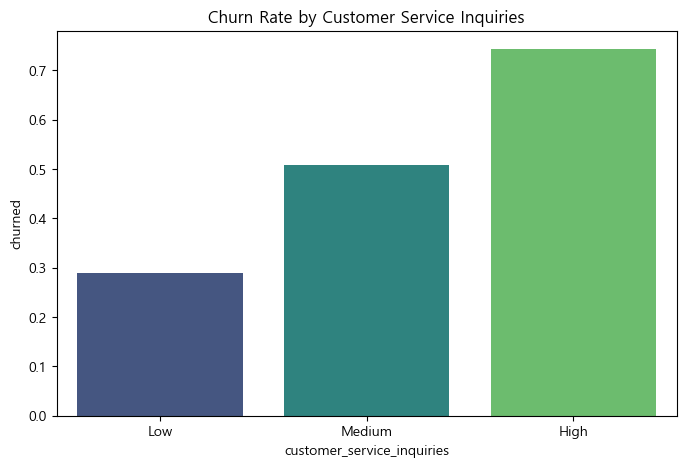

In [49]:
plt.figure(figsize=(8, 5))
inquiry_order = ['Low', 'Medium', 'High']
inquiry_churn = model_df.groupby('customer_service_inquiries')['churned'].mean().reindex(inquiry_order).reset_index()

# 수정: hue='customer_service_inquiries' 및 legend=False 추가
sns.barplot(x='customer_service_inquiries', y='churned', data=inquiry_churn,
            hue='customer_service_inquiries', palette='viridis', legend=False)

plt.title('Churn Rate by Customer Service Inquiries')
plt.show()

- 분석결과: 가장 강력한 양의 상관관계. 문의가 'High'인 그룹의 이탈률이 'Low' 그룹보다 2.5배 이상 높음.

In [50]:
mapping = {'Low': 0, 'Medium': 1, 'High': 2}
model_df['inquiries_num'] = model_df['customer_service_inquiries'].map(mapping)
print(model_df[['tenure_days', 'engagement_score', 'inquiries_num', 'churned']].corr()['churned'])

tenure_days         0.0012
engagement_score   -0.1717
inquiries_num       0.3712
churned             1.0000
Name: churned, dtype: float64


# 4. 지도 시각화

In [51]:
# location 컬럼을 기준으로 그룹화하여 전체 고객 수와 이탈 고객 수 계산
state_churn_analysis = model_df.groupby('location')['churned'].agg(['count', 'sum']).reset_index()

# 컬럼명 변경
state_churn_analysis.columns = ['state', 'total_customers', 'churned_customers']

# 이탈률 계산
# 이탈률 = (이탈 고객 수 / 전체 고객 수)
state_churn_analysis['churn_rate'] = state_churn_analysis['churned_customers'] / state_churn_analysis['total_customers']

# 이탈률을 퍼센트로 변환하고 소수점 둘째 자리까지 반올림
state_churn_analysis['churn_rate_pct'] = round(state_churn_analysis['churn_rate'] * 100, 2)

# 이탈률이 높은 순서대로 정렬
state_churn_analysis = state_churn_analysis.sort_values(by='churn_rate_pct', ascending=False)

# 결과 출력
print("State별 이탈률 분석 결과:")
display(state_churn_analysis.head(10))

State별 이탈률 분석 결과:


,state,total_customers,churned_customers,churn_rate,churn_rate_pct
3,Georgia,6705,3497,0.5216,52.1600
16,Washington,6638,3434,0.5173,51.7300
18,Wisconsin,6553,3389,0.5172,51.7200
8,New Jersey,6634,3429,0.5169,51.6900
12,South Carolina,6534,3375,0.5165,51.6500
11,North Dakota,6577,3394,0.5160,51.6000
14,Vermont,6676,3442,0.5156,51.5600
13,Utah,6577,3386,0.5148,51.4800
17,West Virginia,6486,3333,0.5139,51.3900
1,California,6665,3425,0.5139,51.3900


In [52]:
!pip install folium

In [53]:
# 공백 제거 및 첫 글자만 대문자로 통일
state_churn_analysis['state'] = state_churn_analysis['state'].str.strip().str.title()

In [54]:
# 미국 50개 주 전체 리스트
us_states_full = [
    'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut',
    'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa',
    'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan',
    'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
    'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio',
    'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota',
    'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia',
    'Wisconsin', 'Wyoming'
]

# 데이터에 없는 주 출력
missing_states = [s for s in us_states_full if s not in state_churn_analysis['state'].values]
print("데이터에 없어 색이 안 칠해지는 주:", missing_states)

데이터에 없어 색이 안 칠해지는 주: ['Alaska', 'Arizona', 'Arkansas', 'Colorado', 'Connecticut', 'Delaware', 'Hawaii', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Nevada', 'New Hampshire', 'New Mexico', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Dakota', 'Tennessee', 'Texas', 'Wyoming']


In [55]:
import folium
import requests

# 1. 미국 주 경계 데이터 로드
url = 'https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/us-states.json'
state_geo = requests.get(url).json()

# 주요 State의 위도/경도 좌표
state_coords = {
    'California': [36.7783, -119.4179], 'Texas': [31.9686, -99.9018],
    'Florida': [27.6648, -81.5158], 'New York': [40.7128, -74.0060],
    'Pennsylvania': [41.2033, -77.1945], 'Illinois': [40.6331, -89.3985],
    'Ohio': [40.4173, -82.9071], 'Georgia': [32.1656, -82.9001],
    'North Carolina': [35.7596, -79.0193], 'Michigan': [44.3148, -85.6024],
    'Washington': [47.7511, -120.7401], 'Arizona': [34.0489, -111.0937],
    'Massachusetts': [42.4072, -71.3824], 'Tennessee': [35.5175, -86.5804],
    'Indiana': [40.2672, -86.1349], 'Missouri': [37.9643, -91.8318],
    'Maryland': [39.0458, -76.6413], 'Wisconsin': [43.7844, -88.7879],
    'Colorado': [39.5501, -105.7821]
}

# 지도 객체 생성
m = folium.Map(location=[37.0902, -95.7129], zoom_start=4)

# 단계구분도 그리기
folium.Choropleth(
    geo_data=state_geo,
    data=state_churn_analysis,
    columns=['state', 'churn_rate_pct'],
    key_on='feature.properties.name',
    fill_color='YlOrRd',
    nan_fill_color='lightgrey',
    legend_name='Customer Churn Rate (%)'
).add_to(m)

# 이탈률 TOP 3 지역에 마커 추가
top_3_states = state_churn_analysis.head(3)

for index, row in top_3_states.iterrows():
    state_name = row['state']
    churn_val = row['churn_rate_pct']

    # 좌표 데이터가 있는 경우에만 지도 위에 마커핀를 찍음
    if state_name in state_coords:
        folium.Marker(
            location=state_coords[state_name],
            popup=f"위험 지역: {state_name} ({churn_val}%)",
            icon=folium.Icon(color='red', icon='info-sign')
        ).add_to(m)

    # 콘솔에도 정보 출력
    print(f"위험 지역 강조: {state_name} ({churn_val}%)")

# 6. 최종 지도 출력
display(m)

위험 지역 강조: Georgia (52.16%)
위험 지역 강조: Washington (51.73%)
위험 지역 강조: Wisconsin (51.72%)
